# Stress intensity factors from an ice-sheet state

This notebook evaluates the surface and basal mode-I stress intensity factors in the VdV formulation in [damage_law.pdf](damage_law.pdf). The calculation takes a prescribed mechanical state and existing crack geometry. It predicts the propagation tendency of those cracks; it does not evolve the ice or prescribe a kinetic law. All examples below are synthetic calculations, not observations.

The function is `stress_intensity_factors(state)` in `stress_intensity.py`. Its only runtime dependency is NumPy. Scalar states and broadcastable arrays use the same function.

## State, units, and assumptions

| State entry | Meaning | SI units / shape |
|---|---|---|
| `thickness` | Ice thickness $H$ | m |
| `membrane_stress` | Horizontal membrane stress tensor $M$ | Pa; final two axes $(2,2)$ |
| `crack_normal` | Unit horizontal normal to both crack families | dimensionless; final axis $(2,)$ |
| `surface_depth`, `basal_depth` | Existing crack depths $a_s,a_b$ | m |
| `surface_water_depth` | Water-column height above the surface crack tip | m; between zero and $a_s$ |
| `basal_water_pressure` | Water pressure at the basal crack mouth | Pa |

The tensor is a **stress**, not a thickness-integrated force. Under the shallow, hydrostatic approximation, $M=\tau_h+\mathrm{tr}(\tau_h)I$ and the crack-normal resistive stress is

$$R_n=\mathbf n^\mathsf T M\mathbf n=2\tau_{nn}+\tau_{tt}.$$

The host model supplies $M$ consistently with its rheology. This function adds no viscosity weakening or extra ligament-stress amplification. An Icepack stress in MPa must be multiplied by $10^6$ before use. If damage fractions are available, use $a_s=HD_s$ and $a_b=HD_b$. Velocity by itself is insufficient: calculating stress from velocity would require a rheology, and calculating stress intensity also requires crack geometry.

The VdV calculation assumes depth-uniform $R_n$, hydrostatic ice and water, isolated mode-I edge cracks in a rectangular slab, and $a_s,a_b>0$ with $a_s+a_b<H$. Surface water height and basal mouth pressure are prescribed boundary conditions. The finite-slab functions do not resolve grounded basal contact or interaction of the two cracks. The surface-water and basal-water densities default to 1,000 and 1,024 kg/m³; ice density is 917 kg/m³ and gravity is 9.81 m/s². The densities can be changed explicitly.

The outputs $(K_{\mathrm{I}}^s,K_{\mathrm{I}}^b)$ have units Pa $\sqrt{\mathrm{m}}$. The function retains negative values as formal closing tendencies, without solving crack-face contact. The separate LEFM propagation criterion is $K_{\mathrm{I}}>K_{\mathrm{Ic}}$; fracture toughness does not enter the calculation of $K_{\mathrm{I}}$ itself.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from stress_intensity import stress_intensity_factors

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
figures = Path('figures')
figures.mkdir(exist_ok=True)
rho_i, g, Kc = 917.0, 9.81, 1e5
state = {
    'thickness': 400.0,
    'membrane_stress': np.array([[150e3, 0], [0, 75e3]]),
    'crack_normal': np.array([1.0, 0.0]),
    'surface_depth': 20.0,
    'basal_depth': 60.0,
    'surface_water_depth': 0.0,
    'basal_water_pressure': rho_i*g*400,
}
ks, kb = stress_intensity_factors(state)
print(f'Surface K_I = {ks/1e6:.4f} MPa sqrt(m)')
print(f'Basal   K_I = {kb/1e6:.4f} MPa sqrt(m)')
print(f'For K_Ic = {Kc/1e6:.2f} MPa sqrt(m): surface active = {ks>Kc}, basal active = {kb>Kc}')

Surface K_I = 0.3401 MPa sqrt(m)
Basal   K_I = 1.9733 MPa sqrt(m)
For K_Ic = 0.10 MPa sqrt(m): surface active = True, basal active = True


## Crack depth and water pressure

For the surface calculation, the water-column height is a prescribed fraction of crack depth. For the basal calculation, mouth pressure is a prescribed fraction of ice overburden. The other crack remains at its reference depth, so the two families retain a positive intervening ligament throughout each sweep. The dashed lines mark an illustrative toughness of 0.1 MPa $\sqrt{\mathrm{m}}$.

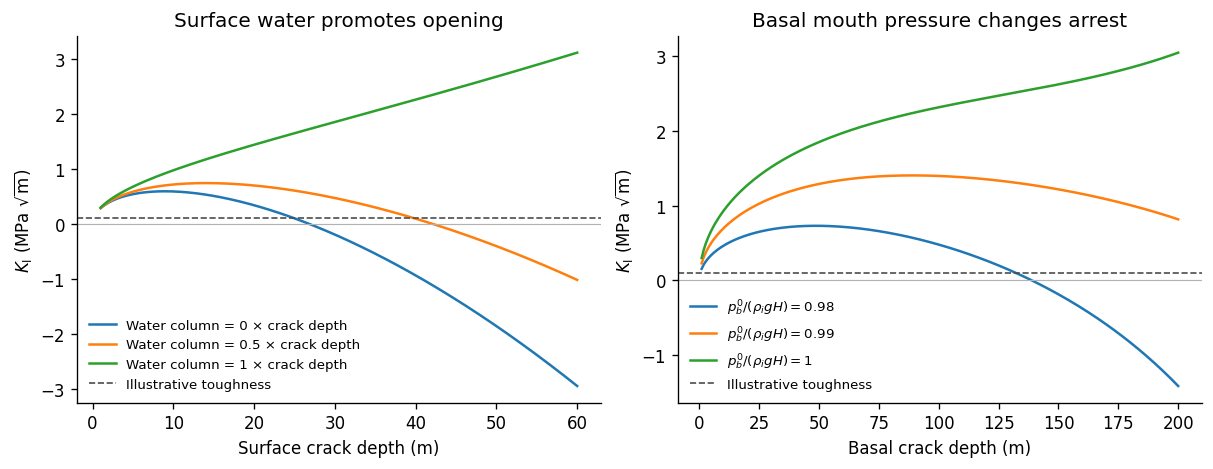

Dry surface-crack arrest depth: 25.05760 m


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout='constrained')
surface_depth = np.linspace(1, 60, 240)
for fraction in (0.0, 0.5, 1.0):
    case = state | {'surface_depth': surface_depth,
                    'surface_water_depth': fraction*surface_depth}
    ks, _ = stress_intensity_factors(case)
    axes[0].plot(surface_depth, ks/1e6, label=f'Water column = {fraction:g} × crack depth')

basal_depth = np.linspace(1, 200, 240)
for support in (.98, .99, 1.0):
    case = state | {'basal_depth': basal_depth,
                    'basal_water_pressure': support*rho_i*g*state['thickness']}
    _, kb = stress_intensity_factors(case)
    axes[1].plot(basal_depth, kb/1e6, label=fr'$p_b^0/(\rho_i gH)={support:g}$')
for ax in axes:
    ax.axhline(Kc/1e6, color='0.3', ls='--', lw=1, label='Illustrative toughness')
    ax.axhline(0, color='0.7', lw=.7)
    ax.set_ylabel(r'$K_{\mathrm{I}}$ (MPa $\sqrt{\mathrm{m}}$)')
    ax.legend(frameon=False, fontsize=8)
axes[0].set(xlabel='Surface crack depth (m)', title='Surface water promotes opening')
axes[1].set(xlabel='Basal crack depth (m)', title='Basal mouth pressure changes arrest')
fig.savefig(figures/'stress_intensity_depth.png', dpi=180)
plt.show()

arrest = brentq(lambda depth: stress_intensity_factors(
    state | {'surface_depth': depth})[0]-Kc, 1, 60)
print(f'Dry surface-crack arrest depth: {arrest:.5f} m')

**Figure 1.** Surface and basal stress intensities at $H=400$ m and $R_n=150$ kPa. Raising the surface water column or basal mouth pressure increases the opening stress intensity. The dry surface curve crosses toughness on its descending branch, defining a stable arrest depth for a propagating crack. The surface sweep has $a_b=60$ m; the basal sweep has $a_s=20$ m. These curves evaluate the full finite-slab LEFM integrals, not the reduced zero-stress approximation.

## Crack orientation

The next calculation rotates the crack normal through a fixed stress tensor. It tests the tensor-to-normal-stress part of the state interface. The two tips share a normal in this model; the examples do not assume that pre-existing cracks instantaneously rotate toward the maximum principal stress.

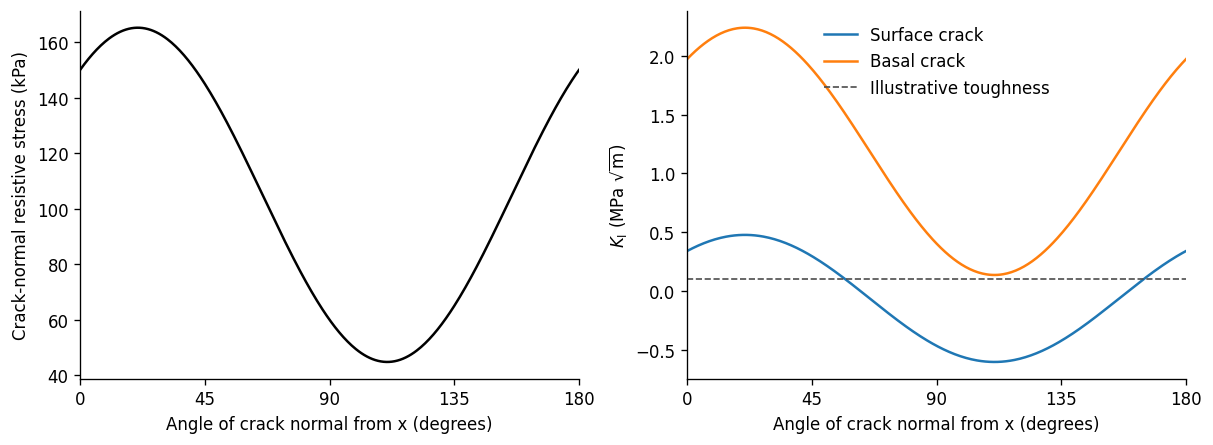

In [3]:
angles = np.linspace(0, np.pi, 361)
normal = np.stack((np.cos(angles), np.sin(angles)), axis=-1)
stress = np.array([[150e3, 40e3], [40e3, 60e3]])
case = state | {'membrane_stress': stress, 'crack_normal': normal}
ks, kb = stress_intensity_factors(case)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout='constrained')
r = np.einsum('...i,ij,...j->...', normal, stress, normal)
axes[0].plot(np.degrees(angles), r/1000, color='black')
axes[0].set(ylabel='Crack-normal resistive stress (kPa)')
axes[1].plot(np.degrees(angles), ks/1e6, label='Surface crack')
axes[1].plot(np.degrees(angles), kb/1e6, label='Basal crack')
axes[1].axhline(Kc/1e6, color='0.3', ls='--', lw=1, label='Illustrative toughness')
axes[1].set_ylabel(r'$K_{\mathrm{I}}$ (MPa $\sqrt{\mathrm{m}}$)')
axes[1].legend(frameon=False)
for ax in axes:
    ax.set(xlabel='Angle of crack normal from x (degrees)', xlim=(0, 180), xticks=[0,45,90,135,180])
fig.savefig(figures/'stress_intensity_orientation.png', dpi=180)
plt.show()
np.testing.assert_allclose([ks[0], kb[0]], [ks[-1], kb[-1]])

**Figure 2.** Crack-normal stress and stress intensities for $M_{xx}=150$, $M_{yy}=60$, and $M_{xy}=40$ kPa. Thickness, depths, and water conditions are those of the reference state. Normals separated by 180° describe the same crack plane and give identical stress intensities. Resolving the stress normal to the crack changes the inferred propagation tendency even though the tensor is unchanged.

## A two-dimensional array state

The same call evaluates a whole map. Here thickness decreases from 400 to 300 m along $x$, and $M_{xx}$ increases from 20 to 180 kPa across $y$. We prescribe $M_{yy}=75$ kPa, $M_{xy}=0$, and $\mathbf n=(1,0)$. Surface and basal depths remain 20 and 60 m. The surface water column increases from 0 to 10 m along $x$; basal mouth pressure is $\rho_i gH$.

These fields illustrate array input. They are prescribed independently, **not obtained from an ice-flow solution**. Black contours on the output maps show the illustrative toughness threshold, rather than an observed fracture boundary.

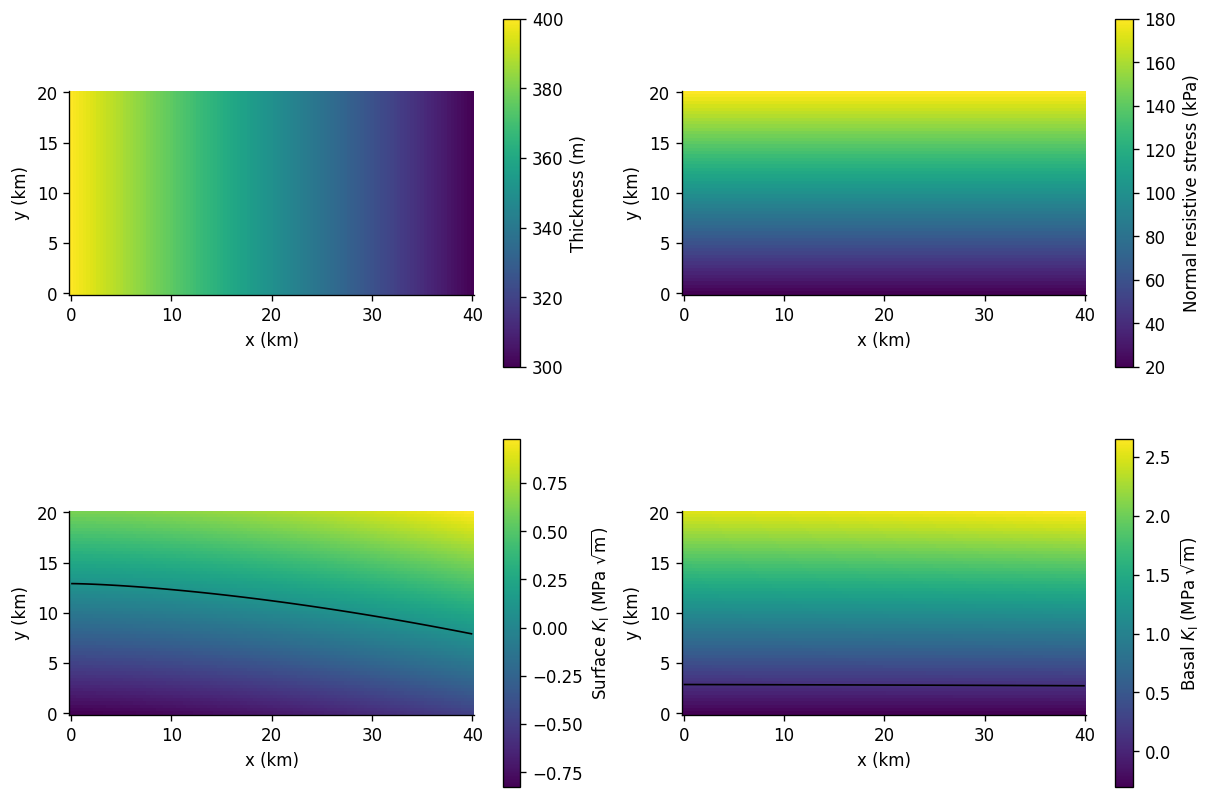

Input grid and both output shapes: (61, 121) (61, 121) (61, 121)


In [4]:
x = np.linspace(0, 40e3, 121)
y = np.linspace(0, 20e3, 61)
X, Y = np.meshgrid(x, y)
H = 400-100*X/40e3
M = np.zeros(X.shape+(2, 2))
M[..., 0, 0] = (20+160*Y/20e3)*1000
M[..., 1, 1] = 75e3
map_state = state | {'thickness': H, 'membrane_stress': M,
                     'surface_water_depth': 10*X/40e3,
                     'basal_water_pressure': rho_i*g*H}
ks_map, kb_map = stress_intensity_factors(map_state)
assert ks_map.shape == kb_map.shape == X.shape
fig, axes = plt.subplots(2, 2, figsize=(10, 7), layout='constrained')
fields = [H, M[..., 0, 0]/1000, ks_map/1e6, kb_map/1e6]
labels = ['Thickness (m)', 'Normal resistive stress (kPa)',
          r'Surface $K_{\mathrm{I}}$ (MPa $\sqrt{\mathrm{m}}$)',
          r'Basal $K_{\mathrm{I}}$ (MPa $\sqrt{\mathrm{m}}$)']
for ax, values, label in zip(axes.flat, fields, labels):
    colors = ax.pcolormesh(x/1000, y/1000, values, shading='auto', cmap='viridis')
    fig.colorbar(colors, ax=ax, label=label, shrink=.85)
    ax.set(xlabel='x (km)', ylabel='y (km)', aspect='equal')
for ax, values in zip(axes[1], [ks_map, kb_map]):
    ax.contour(x/1000, y/1000, values, levels=[Kc], colors='black', linewidths=1)
fig.savefig(figures/'stress_intensity_map.png', dpi=180)
plt.show()
print('Input grid and both output shapes:', X.shape, ks_map.shape, kb_map.shape)

**Figure 3.** Prescribed thickness and crack-normal stress (top), and calculated surface and basal stress intensities (bottom). Crack depths are spatially uniform, so differences in the propagation criterion arise from the stress, thickness, and water-pressure fields. This example verifies the map interface; it is not a prognostic shelf simulation.

## Numerical accuracy and observational prediction

The quadrature substitutes $y/a=\sin\theta$ to remove the integrable tip singularity in the VdV weight function. Pressure integrals stop at their waterlines, so the quadrature does not straddle a hydrostatic pressure kink. The following comparison checks the 32-point default against 128 points for the entire map. Automated tests additionally compare against independent adaptive integration in the original coordinate and exercise a basal tip above the waterline.

In [5]:
reference = stress_intensity_factors(map_state, quadrature_order=128)
error = max(float(np.max(np.abs(k-ref))) for k, ref in zip((ks_map, kb_map), reference))
scale = max(float(np.max(np.abs(ref))) for ref in reference)
print(f'Maximum 32- versus 128-point difference: {error:.3e} Pa sqrt(m)')
print(f'Difference relative to maximum |K|: {error/scale:.3e}')
assert error/scale < 1e-6

Maximum 32- versus 128-point difference: 2.822e-03 Pa sqrt(m)
Difference relative to maximum |K|: 1.063e-09


Given measured or modeled thickness, stress, water conditions, and crack orientation, this calculation predicts whether an existing crevasse exceeds toughness. A propagating crack that arrests on a stable branch should satisfy $K_{\mathrm{I}}(a)=K_{\mathrm{Ic}}$. Measured arrest depths could test that prediction without selecting a crack-speed law.

The main limitations are the assumed depth-uniform resistive stress, isolated edge-crack geometry, prescribed water supply, and omission of basal contact and crack interactions. The function rejects zero-length flaws and through-thickness connection because they lie outside the stated model. It does not supply a nucleation law, enforce a calving criterion, or infer water pressures from thickness.